# CS242 Part B BERT Indexing

In [1]:
!pip install torch transformers tqdm numpy

If you use gpu install faiss-gpu

In [2]:
!pip install faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 17.9 MB/s eta 0:00:00


else install faiss-cpu

In [ ]:
!pip install faiss-cpu

Found existing installation: faiss-cpu 1.13.2
Uninstalling faiss-cpu-1.13.2:
  Successfully uninstalled faiss-cpu-1.13.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 17.1 MB/s eta 0:00:00


Use Data from Google drive. If you run this locally, you can ignore this and the unzip part.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip -q "/content/drive/MyDrive/movies.zip" -d "/content/dataset"

In [5]:
import os
import json
import time
import torch
import numpy as np
import faiss

from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel

Set some constant.  
You should change DATASET_PATH to your data dir

In [6]:
DATASET_PATH = "/content/dataset/movies"  # change this to your data path

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

BATCH_SIZE = 64

INDEX_FILE = "movie_faiss.index"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model = model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-5): 6 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
    

In [8]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0]
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(
        input_mask_expanded.sum(1),
        min=1e-9
    )

Ceate passage for BERT  
I repeat the {title} 3 times for increasing its weight

In [9]:
def movie_to_text(movie):
    title = movie.get("title", "")
    overview = movie.get("overview", "")
    tagline = movie.get("tagline", "")
    genres = " ".join([g["name"] for g in movie.get("genres", [])])
    cast = " ".join([c["name"] for c in movie.get("cast", [])[:5]])
    directors = " ".join([
        c["name"] for c in movie.get("crew", [])
        if c.get("job") == "Director"
    ])

    text = f"""
    Title: {title} {title} {title}
    Overview: {overview}
    Tagline: {tagline}
    Genres: {genres}
    Cast: {cast}
    Director: {directors}
    """

    return text.strip()

Create faiss index

In [10]:
dimension = 384
index = faiss.IndexFlatL2(dimension)

BERT indexing  
You can edit the **movie_metadata** structure if you want to add more attributes.

In [12]:
batch_texts = []
movie_ids = []
movie_metadata = []

doc_counts = []
runtimes = []
checkpoint_interval = 5000

start_time = time.time()

all_files = []
for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".json"):
            all_files.append(os.path.join(root, file))

for i, path in enumerate(tqdm(all_files, desc="Indexing")):
    with open(path, "r", encoding="utf-8") as f:
        movie = json.load(f)

    text = movie_to_text(movie)
    batch_texts.append(text)

    countries = [c.get("name") for c in movie.get("production_countries", [])]
    country_codes = [c.get("iso_3166_1") for c in movie.get("production_countries", [])]

    movie_metadata.append({
        "id": movie["id"],
        "imdb_id": movie.get("imdb_id"),
        "title": movie.get("title"),
        "overview": movie.get("overview"),
        "genres": [g["name"] for g in movie.get("genres", [])],
        "release_date": movie.get("release_date"),
        "vote_average": movie.get("vote_average"),
        "countries": countries,
        "country_codes": country_codes,
        "origin_country": movie.get("origin_country", []),
        "reviews": movie.get("reviews", [])
    })

    movie_ids.append(movie["id"])

    if len(batch_texts) == BATCH_SIZE:
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            model_output = model(**inputs)

        embeddings = mean_pooling(
            model_output,
            inputs["attention_mask"]
        )

        vectors = embeddings.cpu().numpy().astype("float32")
        index.add(vectors)
        batch_texts = []


    current_count = i + 1
    if current_count % checkpoint_interval == 0:
        elapsed = time.time() - start_time
        doc_counts.append(current_count)
        runtimes.append(elapsed)


if batch_texts:
    inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors="pt"
        ).to(device)

    with torch.no_grad():
        model_output = model(**inputs)

    embeddings = mean_pooling(
        model_output,
        inputs["attention_mask"]
    )
    vectors = embeddings.cpu().numpy().astype("float32")
    index.add(vectors)


doc_counts.append(len(all_files))
runtimes.append(time.time() - start_time)

end_time = time.time()
bert_indexing_time = end_time - start_time
print("Total indexed vectors:", index.ntotal)
print("BERT Indexing Time:", bert_indexing_time, "seconds")

Indexing: 100%|██████████| 220015/220015 [11:08<00:00, 329.30it/s]


Total indexed vectors: 220015
BERT Indexing Time: 669.1075172424316 seconds


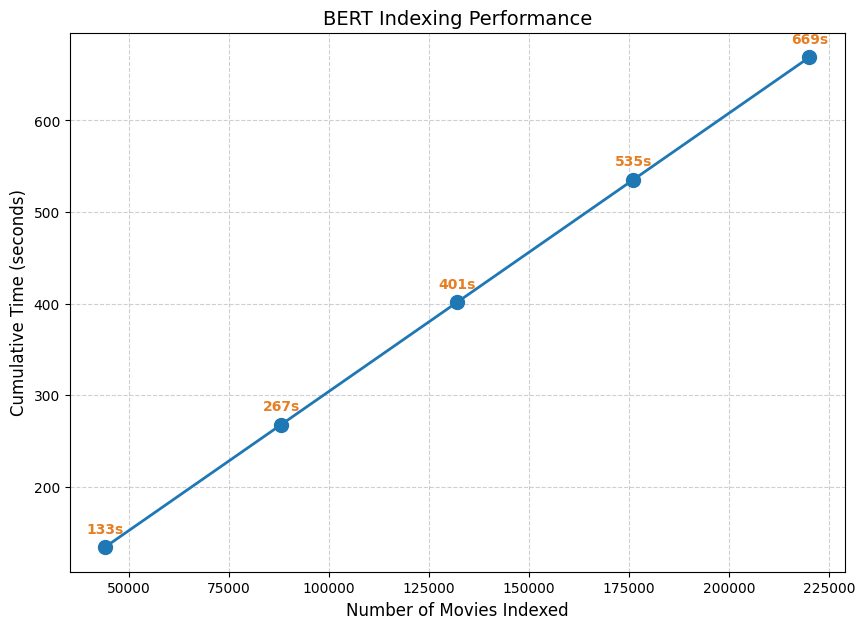

In [25]:
import matplotlib.pyplot as plt
import numpy as np

total_docs = index.ntotal
total_time = bert_indexing_time


doc_counts = np.linspace(0, total_docs, 6)[1:]
runtimes = np.linspace(0, total_time, 6)[1:]


plt.figure(figsize=(10, 7))
plt.plot(doc_counts, runtimes, marker='o', markersize=10,
         linestyle='-', color='#1f77b4', linewidth=2)


for x, y in zip(doc_counts, runtimes):
    plt.annotate(f'{int(y)}s',
                 xy=(x, y),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center',
                 fontsize=10,
                 fontweight='bold',
                 color='#e67e22')


plt.title('BERT Indexing Performance', fontsize=14)
plt.xlabel('Number of Movies Indexed', fontsize=12)
plt.ylabel('Cumulative Time (seconds)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)


plt.show()

Save faiss index

In [26]:
faiss.write_index(index, INDEX_FILE)

print("Index saved:", INDEX_FILE)

Index saved: movie_faiss.index


Check index

In [27]:
index = faiss.read_index(INDEX_FILE)

print("Index loaded")

print("Total vectors:", index.ntotal)

Index loaded
Total vectors: 220015


In [28]:
def encode_query(query):

    inputs = tokenizer(
        query,
        return_tensors="pt",
        truncation=True
    ).to(device)

    with torch.no_grad():

        model_output = model(**inputs)

    embedding = mean_pooling(
        model_output,
        inputs["attention_mask"]
    )

    return embedding.cpu().numpy().astype("float32")

Save movie metadata for search display

In [29]:
import pickle

metadata_file = "movie_metadata.pkl"

with open(metadata_file, "wb") as f:
    pickle.dump(movie_metadata, f)

print(f"Metadata saved: {len(movie_metadata)} records")

with open(metadata_file, "rb") as f:
    test_load = pickle.load(f)
    print(f"Successfully reloaded {len(test_load)} records")

Metadata saved: 220015 records
Successfully reloaded 220015 records


In [30]:
def search_movies(query, top_k=5):

    query_vector = encode_query(query)

    distances, indices = index.search(query_vector, top_k)

    results = []

    for i, idx in enumerate(indices[0]):

        movie = movie_metadata[idx]

        results.append({
            "rank": i + 1,
            "score": float(distances[0][i]),
            "id": movie["id"],
            "imdb_id": movie["imdb_id"],
            "title": movie["title"],
            "overview": movie["overview"],
            "genres": movie["genres"],
            "release_date": movie["release_date"],
            "rating": movie["vote_average"],
            "origin_country": movie["origin_country"],
            "reviews": movie["reviews"]
        })

    return results

In [31]:
import textwrap

def display_results(results):

    for r in results:

        print("=" * 60)

        print(f"Rank #{r['rank']}")
        print("Title:", r["title"])
        print("Release:", r["release_date"])
        print("Rating:", r["rating"])
        print("Origin Countries:", ", ".join(r["origin_country"]))

        if r.get("imdb_id"):
            print(f"IMDb Link: https://www.imdb.com/title/{r['imdb_id']}/")
        print(f"TMDb Link: https://www.themoviedb.org/movie/{r['id']}")

        print("Genres:", ", ".join(r["genres"]))

        print("\nOverview:")
        wrapped_overview = textwrap.fill(r["overview"][:200], width=100)
        print(wrapped_overview)
        # print("\nReviews:", r["reviews"])
        # wrapped_reviews = textwrap.fill(r["reviews"], width=100)
        # print(wrapped_reviews)
        print("")
        print(f"Similarity Score: {r["score"]:.3f}")

In [32]:
query = "Everthing Everywhere"

results = search_movies(query, top_k=5)

display_results(results)

Rank #1
Title: Almost Everything You Ever Wanted to Know About Everything Everywhere All at Once
Release: 2022-07-05
Rating: 10.0
Origin Countries: US
TMDb Link: https://www.themoviedb.org/movie/1258497
Genres: Documentary

Overview:
A behind-the-scenes look at Everything Everywhere All at Once, with interviews from the
directors/writers, cast and crew.

Similarity Score: 30.822
Rank #2
Title: Anywhere Else
Release: 2014-02-07
Rating: 6.1
Origin Countries: DE
IMDb Link: https://www.imdb.com/title/tt3454856/
TMDb Link: https://www.themoviedb.org/movie/280894
Genres: Comedy, Drama

Overview:
You left your home to move far away. You were struck by a wind of change and were unfaithful to
yourself. You reinvented yourself and you are now feeling free. But suddenly pressure arises in you.

Similarity Score: 31.228
Rank #3
Title: Everything Everywhere All at Once
Release: 2022-03-24
Rating: 7.722
Origin Countries: US
IMDb Link: https://www.imdb.com/title/tt6710474/
TMDb Link: https://www.them